
### import tools

In [1]:
import pandas as pd
from typing import List, Dict
from tqdm.notebook import tqdm
import numpy as np
import matplotlib.pyplot as plt

In [2]:
from datasets import load_dataset
# dataset = load_dataset("imdb")
dataset = load_dataset("scikit-learn/imdb")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


README.md: 0.00B [00:00, ?B/s]

IMDB Dataset.csv:   0%|          | 0.00/66.2M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/50000 [00:00<?, ? examples/s]

# Course plan
1. Machine learning for NLP
2. Course + TP: Attention and transformers
3. Course: Transformers and pre-training
4. TP: Coding GPT
5. TP: Coding GPT Part 2 + BERT
6. Evaluation of LLMs

2 homeworks.
One graded TP.
One project.

# Evaluation
- 25% Homework
- 25% TP
- 50% Project

# Machine learning for NLP

🚧 **Question** 🚧

Why would one need NLP?

🚧 **Question** 🚧

Can you give two main domain of NLP applications?

# First application: text classification

- Goal of text classification: assign a label to a text.
- We actually want to model $p(y | x)$ where $x$ is the text and $y$ is the label.
- Let's call $\hat{p}$ our model. $\hat{p}$ is a function that takes a text as input and outputs a label.

🚧 **Question** 🚧

How would you model $\hat{p}$?


In [3]:
from datasets import load_dataset
dataset = load_dataset("scikit-learn/imdb")

print(dataset)
df = pd.DataFrame(dataset['train'][:5000])
df.head()

DatasetDict({
    train: Dataset({
        features: ['review', 'sentiment'],
        num_rows: 50000
    })
})


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [49]:
from sklearn.model_selection import train_test_split

X = df["review"]
y = (df["sentiment"] == "positive").astype(int)


X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1234
)
X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [50]:
print(X_train)
X_train.shape

0       I mean really. This is not going to help the A...
1       I'll give writer/director William Gove credit ...
2       Joseph Brady and Clarence Doolittle are two sa...
3       You know you're in trouble when the film your ...
4       This has to be, by far, the absolute worst mov...
                              ...                        
3495    A flying saucer manned (literally) by a crew o...
3496    All y'all hatin' on the fact you'd probably ne...
3497    Just how bad? Well, compared to this movie, Ca...
3498    For Greta Garbo's first talking picture, MGM w...
3499    I was going to say this was the worst gay-them...
Name: review, Length: 3500, dtype: object


(3500,)

# Tokenization
Tokenizing a text means splitting it into words.

This is not as easy as it seems. For instance, how would you tokenize the following text?

```
I'm a student.
```

- We can naively split on spaces.
- We can use a library like `nltk`, that incorporates more rules to split the text.

In [51]:
from nltk import word_tokenize

In [52]:
import nltk
nltk.download('punkt_tab')
word_tokenize("Hello world. I'm Florian")

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


['Hello', 'world', '.', 'I', "'m", 'Florian']

In [53]:
import unicodedata
import re

In [54]:
def preprocess_text(text: str) -> str:
    # DM
    # Normalize to decomposed form (NFD)
    text = unicodedata.normalize('NFD', text)
    # Remove combining diacritical marks (Unicode range)
    text = re.sub(r'[\u0300-\u036f]', '', text)
    return text

In [55]:
noisy_text = "Ï   lîved  in    San-Françisco...  ! for 12 years."
preprocess_text(noisy_text)

'I   lived  in    San-Francisco...  ! for 12 years.'

In [56]:
X_train = X_train.apply(preprocess_text)
X_test = X_test.apply(preprocess_text)

In [57]:

class WhiteSpaceTokenizer:
    def __init__(self):
        # The vocabulary will store the mapping between text tokens and their id.
        self.vocab = {}
        self.id_to_token = {}

        # We will keep track of the number of times a word appears in the corpus.
        self.frequencies = {}

    def split_text(self, text: str) -> List[str]:
        """Converts the text to a list of tokens (substrings)."""
        return word_tokenize(text)

    def encode(self, text: str) -> List[int]:
        """Take a text as input and return its associated tokenization, as a list of ids."""
        list_tokens = self.split_text(text)
        list_ids = []
        for token in list_tokens:
            list_ids.append(self.vocab.get(token, -1))
        return list_ids

    def decode(self, ids: List[int]) -> str:
        tokens = [self.id_to_token[i] for i in ids]
        return " ".join(tokens)

    def fit(self, corpus: List[str]):
        """Fits the tokenizer to a list of texts to construct its vocabulary."""
        current_id = 0
        for text in tqdm(corpus):
            list_tokens = self.split_text(text)
            for token in list_tokens:
                token_id = self.vocab.get(token, None)
                if token_id is None:
                    self.vocab[token] = current_id
                    self.id_to_token[current_id] = token
                    self.frequencies[current_id] = 0
                    token_id = current_id
                    current_id += 1

                self.frequencies[token_id] += 1
        self.num_words = current_id
        self.vocab["<UNK>"] = -1
        self.id_to_token[-1] = "<UNK>"
        print(f"\nBuilt a vocabulary of {self.num_words} words.")

In [58]:
tokenizer = WhiteSpaceTokenizer()
tokenizer.fit(X_train)

  0%|          | 0/3500 [00:00<?, ?it/s]


Built a vocabulary of 46953 words.


In [59]:
text = "i live in pÂris"
token_ids = tokenizer.encode(text)
print("List of tokens:", token_ids)
print("decoded tokens:", tokenizer.decode(token_ids))

text_ = preprocess_text(text)
print('\n', text_)
token_ids = tokenizer.encode(text_)
print("List of tokens:", token_ids)
print("decoded tokens:", tokenizer.decode(token_ids))


text = "i live in Pâris"
text_ = preprocess_text(text)
print('\n', text_)
token_ids = tokenizer.encode(text_)
print("List of tokens:", token_ids)
print("decoded tokens:", tokenizer.decode(token_ids))


List of tokens: [1961, 2669, 156, -1]
decoded tokens: i live in <UNK>

 i live in pAris
List of tokens: [1961, 2669, 156, -1]
decoded tokens: i live in <UNK>

 i live in Paris
List of tokens: [1961, 2669, 156, 9543]
decoded tokens: i live in Paris


In [60]:
class BaseTextClassifier:

    def predict(self, text: str) -> int:
        raise NotImplementedError()

    def predict_dataset(self, X: List[str]) -> List[int]:
        return [self.predict(x) for x in X]

    def evaluate(self, X: List[str], y: List[int]) -> Dict[str, float]:
        predictions = self.predict_dataset(X)
        y_array = np.array(y)
        accuracy = np.mean(predictions == y_array)
        return {"accuracy": accuracy}

In [61]:
class CountClassifier(BaseTextClassifier):
    def __init__(self, n_classes):
        self.n_classes = n_classes
        self.tokenizer = WhiteSpaceTokenizer()

    def get_word_count(self, X, y):
        words_count = np.zeros((self.n_classes, self.tokenizer.num_words), dtype=int)
        for i in range(len(X)):
            tokens = self.tokenizer.encode(X[i])
            for w in tokens:
                if w != -1:
                    words_count[y[i], w] += 1
        return words_count

    def fit(self, X, y):
        self.tokenizer.fit(X)

        word_count = self.get_word_count(X, y)
        self.words_count = word_count

    def predict(self, text: str) -> int:
        """
        Calculate a score for each label by summing
        the number of times each word in 'text' appears in
        the training text (with the given label).
        Then choose the label with the highest score.
        """
        words = self.tokenizer.encode(text)
        words = np.array([w for w in words if w != -1])
        words_count_per_class = self.words_count[:, words]
        scores = words_count_per_class.sum(axis=1)
        return np.argmax(scores)

In [62]:
classifier = CountClassifier(2)
classifier.fit(X_train, y_train)
print(classifier.evaluate(X_test, y_test))

  0%|          | 0/3500 [00:00<?, ?it/s]


Built a vocabulary of 46953 words.
{'accuracy': np.float64(0.61)}


In [63]:
print('a few columns of words_count: \n', classifier.words_count[:, :10] )

# print(classifier.tokenizer.encode('bad'))
print('\n\t\t\t 0 (negaitve) / 1 (positive)')

print('"bad" in words_count: \t\t', classifier.words_count[:,classifier.tokenizer.encode('bad')[0]] )
print('"terrible" in words_count: \t', classifier.words_count[:,classifier.tokenizer.encode('terrible')[0]] )
print('"horrible" in words_count: \t', classifier.words_count[:,classifier.tokenizer.encode('horrible')[0]] )

print('"nice" in words_count: \t\t',  classifier.words_count[:,classifier.tokenizer.encode('nice')[0]] )
print('"wonderful" in words_count: \t',  classifier.words_count[:,classifier.tokenizer.encode('wonderful')[0]] )
print('"great" in words_count: \t',  classifier.words_count[:,classifier.tokenizer.encode('great')[0]] )


a few columns of words_count: 
 [[ 6036   162   819 16553  1037  7031  2035   353  9647   111]
 [ 5077    64   737 15904  1086  8035  1924   233  8904   147]]

			 0 (negaitve) / 1 (positive)
"bad" in words_count: 		 [963 256]
"terrible" in words_count: 	 [187  41]
"horrible" in words_count: 	 [124  21]
"nice" in words_count: 		 [118 130]
"wonderful" in words_count: 	 [ 46 205]
"great" in words_count: 	 [320 813]


In [64]:
class FrequencyClassifier(BaseTextClassifier):
    def __init__(self, n_classes):
        self.n_classes = n_classes
        # This attribute is not used, but kept for API consistency
        self.tokenizer = WhiteSpaceTokenizer()

    def get_word_count(self, X, y):
        words_count = np.zeros((self.n_classes, self.tokenizer.num_words), dtype=int)
        for i in range(len(X)):
            tokens = self.tokenizer.encode(X[i])
            for w in tokens:
                if w != -1:
                    words_count[y[i], w] += 1
        frequencies = words_count / words_count.sum(axis=1, keepdims=True)
        return words_count, frequencies

    def fit(self, X, y):
        self.tokenizer.fit(X)

        word_count, frequencies = self.get_word_count(X, y)
        self.frequencies = frequencies
        self.words_count = word_count

    def predict(self, text: str) -> int:
        """
        Calculate a score for each label by summing
        the normalized frequencies of the words in 'text'.
        Then choose the label with the highest score.
        """
        global_count = self.words_count.sum(axis=0)
        global_freq = global_count / global_count.sum()
        words = self.tokenizer.encode(text)
        words = np.array([w for w in words if w != -1])
        words_count_per_class = self.frequencies[:, words] / global_freq[words]
        scores = words_count_per_class.sum(axis=1)
        return np.argmax(scores)

In [65]:
classifier = FrequencyClassifier(2)
classifier.fit(X_train, y_train)
print(classifier.evaluate(X_test, y_test))

  0%|          | 0/3500 [00:00<?, ?it/s]


Built a vocabulary of 46953 words.
{'accuracy': np.float64(0.8206666666666667)}


In [66]:
print('a few columns of frequencies: \n', classifier.frequencies[:, :10] )

# print(classifier.tokenizer.encode('bad'))
print('\n\t\t\t 0 (negaitve) / 1 (positive)')

print('"bad" in frequencies: \t\t', classifier.frequencies[:,classifier.tokenizer.encode('bad')[0]] )
print('"horrible" in frequencies: \t', classifier.frequencies[:,classifier.tokenizer.encode('horrible')[0]] )

print('"nice" in frequencies: \t\t',  classifier.frequencies[:,classifier.tokenizer.encode('nice')[0]] )
print('"wonderful" in frequencies: \t',  classifier.frequencies[:,classifier.tokenizer.encode('wonderful')[0]] )
print('"great" in frequencies: \t',  classifier.frequencies[:,classifier.tokenizer.encode('great')[0]] )


a few columns of frequencies: 
 [[0.01212764 0.00032549 0.00164555 0.03325859 0.00208356 0.01412681
  0.00408876 0.00070925 0.01938293 0.00022302]
 [0.01042561 0.00013142 0.00151343 0.03265883 0.0022301  0.01649985
  0.00395093 0.00047846 0.01828434 0.00030186]]

			 0 (negaitve) / 1 (positive)
"bad" in frequencies: 		 [0.00193488 0.0005257 ]
"horrible" in frequencies: 	 [2.49143068e-04 4.31234522e-05]
"nice" in frequencies: 		 [0.00023709 0.00026695]
"wonderful" in frequencies: 	 [9.24240415e-05 4.20967033e-04]
"great" in frequencies: 	 [0.00064295 0.00166949]


🚧 **Question** 🚧

How can we optimize the algorithm?

In [67]:
from sklearn.feature_extraction.text import CountVectorizer

vectorizer = CountVectorizer()
X_vec = vectorizer.fit_transform(X.apply(preprocess_text))

X_train, X_test, y_train, y_test = train_test_split(
    X_vec.toarray(), y, test_size=0.3, random_state=1234
)

In [68]:
print(X_train.shape)  # (n, d)

print(X.shape)
print(X_vec.shape)
print(X_vec)

(3500, 38947)
(5000,)
(5000, 38947)
<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 683407 stored elements and shape (5000, 38947)>
  Coords	Values
  (0, 24250)	1
  (0, 24114)	7
  (0, 34654)	16
  (0, 24512)	2
  (0, 28900)	1
  (0, 15720)	1
  (0, 21887)	1
  (0, 34648)	4
  (0, 1013)	1
  (0, 37663)	2
  (0, 18807)	2
  (0, 24788)	6
  (0, 11668)	2
  (0, 38739)	3
  (0, 20361)	3
  (0, 3215)	2
  (0, 16539)	1
  (0, 34725)	1
  (0, 2085)	2
  (0, 29069)	2
  (0, 2243)	4
  (0, 34765)	3
  (0, 18201)	9
  (0, 12004)	1
  (0, 37902)	2
  :	:
  (4999, 18201)	1
  (4999, 21675)	1
  (4999, 37624)	1
  (4999, 1635)	1
  (4999, 13412)	2
  (4999, 35039)	1
  (4999, 11940)	1
  (4999, 35141)	1
  (4999, 22870)	5
  (4999, 20996)	1
  (4999, 13)	1
  (4999, 3678)	1
  (4999, 21003)	1
  (4999, 15617)	1
  (4999, 14493)	1
  (4999, 20876)	1
  (4999, 38432)	1
  (4999, 9802)	1
  (4999, 34745)	1
  (4999, 21431)	1
  (4999, 35921)	1
  (4999, 2202)	1
  (4999, 35595)	1
  (4999, 7773)	1
  (4999, 21441)	1


In [69]:
class FrequencyClassifier(BaseTextClassifier):
    def __init__(self, n_classes):
        self.n_classes = n_classes
        # This attribute is not used, but kept for API consistency

    def get_word_count(self, X, y):
        words_count = np.zeros((self.n_classes, X.shape[-1]), dtype=int)
        for label in range(self.n_classes):
            words_count[label] = X[y == label].sum(axis=0)
        frequencies = words_count / words_count.sum(axis=1, keepdims=True)
        return words_count, frequencies

    def fit(self, X, y):

        word_count, frequencies = self.get_word_count(X, y)
        self.frequencies = frequencies
        self.words_count = word_count
        self.global_count = self.words_count.sum(axis=0) + 1
        self.global_freq = self.global_count / self.global_count.sum()
        self.global_freq = self.global_freq

    def predict(self, x) -> int:
        words_count_per_class = x * self.frequencies / self.global_freq
        scores = words_count_per_class.sum(axis=1)
        return np.argmax(scores)

In [70]:
classifier = FrequencyClassifier(2)
classifier.fit(X_train, y_train)
print(classifier.evaluate(X_test, y_test))

{'accuracy': np.float64(0.8326666666666667)}


In [71]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
accuracy = np.mean(y_pred == y_test)
print(f"Accuracy: {accuracy}")

Accuracy: 0.862


## Vectorization and NLP

- In Machine Learning, we need to work with vectors.
- The challenge is to find meaningful vectors for texts.
- We rely on things we can do easily:
  - Counting words
  - Counting n-grams
  - Ratios between those counts

## Bag of words model

- We count the number of times each word appears in a text.
- We can then represent the text as a vector of counts.

## Frequency-based vectorization

- We can normalize the counts by the total number of words in the text.
- This gives us the frequency of each word in the text.
- This is called the **term frequency**.

## TF-IDF

- **Intuition**:
  - If a word appears many times in a document, it is important.
  - If a word appears in many documents, it is not very informative.
  - For instance, the words "the", "and" appears in many documents.

- **TF-IDF**:
  - We multiply the term frequency by the inverse document frequency.
  - Used a lot for information retrieval.


## Term Frequency (TF)
$$
\text{TF}(t, d) = \frac{f_{t, d}}{\sum_{t' \in d} f_{t', d}}
$$
Where:
- $ f_{t, d} $: Frequency of term $ t $ in document $ d $.
- $ \sum_{t' \in d} f_{t', d} $: Total number of terms in document $ d $.

---

### Inverse Document Frequency (IDF)
$$
\text{IDF}(t) = \log\left(\frac{N + 1}{\text{DF}(t) + 1}\right) + 1
$$
Where:
- $ N $: Total number of documents.
- $ \text{DF}(t) $: Number of documents containing the term $ t $.
- Adding $ +1 $ in numerator and denominator prevents division by zero.

---

### TF-IDF
$$
\text{TF-IDF}(t, d) = \text{TF}(t, d) \times \text{IDF}(t)
$$

In [72]:
def word_count_to_tfidf(word_count_matrix):

    # Term Frequency (TF)
    term_frequencies = word_count_matrix / word_count_matrix.sum(axis=1, keepdims=True)

    # Document Frequency (DF)
    document_frequencies = np.count_nonzero(word_count_matrix > 0, axis=0)

    # Inverse Document Frequency (IDF)
    num_documents = word_count_matrix.shape[0]
    idf = np.log((num_documents + 1) / (document_frequencies + 1)) + 1

    # TF-IDF
    tfidf_matrix = term_frequencies * idf

    return tfidf_matrix

## Application: identifying similar documents

- We can use TF-IDF to identify similar documents.
- To quickly compare two documents, we can compute the cosine similarity between their TF-IDF vectors.

In [73]:
from sklearn.feature_extraction.text import TfidfVectorizer

vectorizer = TfidfVectorizer()
X_vec = vectorizer.fit_transform(X.apply(preprocess_text))

query = "i like film with boats"

query_vec = vectorizer.transform([query])

similarity = X_vec.dot(query_vec.T).toarray().flatten()
most_similar_idx = np.argmax(similarity)

print(X[most_similar_idx])

This is an excellent documentary about a story I hadn't heard about before. The first solo, non-stop sailing race around the world took place in 1968-69 and involved a handful of racers. It's a truly fascinating story about man vs. nature and man vs. himself. The story focuses on Donald Crowhurst, the tragic figure in this story. The film elegantly combines interviews with footage which was shot by the sailors themselves aboard their boats. The story is very suspenseful and sad as we learn the details behind the history of Donald Crowhurst. This is one of the best documentaries of the past few years. It has true human emotion in it as the men face this almost impossible task of navigating the world non-stop on their own.


## Limitations of frequency-based vectorization

- Each word is treated independently, regardless of its context.
- The order of words is not taken into account.
- Semantic information is not captured.

## From document vectors to word embeddings

- **Intuitive example**: Suppose we are interested in classifying texts in 4 categories: "World", "Sports", "Business", "Sci/Tech".

In [ ]:
#!curl -o agnews.json 'https://cdn-lfs.hf.co/repos/1c/c2/1cc270208f262b4321ee4f29ffabdcb8628e94f3f5ff6bdd56b06989d62694b8/68dea4cd08fc6fca98f9cd4f3b173b553f29c65641514505f886683c7a9215ac?response-content-disposition=attachment%3B+filename*%3DUTF-8%27%27train.jsonl%3B+filename%3D%22train.jsonl%22%3B&Expires=1737499439&Policy=eyJTdGF0ZW1lbnQiOlt7IkNvbmRpdGlvbiI6eyJEYXRlTGVzc1RoYW4iOnsiQVdTOkVwb2NoVGltZSI6MTczNzQ5OTQzOX19LCJSZXNvdXJjZSI6Imh0dHBzOi8vY2RuLWxmcy5oZi5jby9yZXBvcy8xYy9jMi8xY2MyNzAyMDhmMjYyYjQzMjFlZTRmMjlmZmFiZGNiODYyOGU5NGYzZjVmZjZiZGQ1NmIwNjk4OWQ2MjY5NGI4LzY4ZGVhNGNkMDhmYzZmY2E5OGY5Y2Q0ZjNiMTczYjU1M2YyOWM2NTY0MTUxNDUwNWY4ODY2ODNjN2E5MjE1YWM%7EcmVzcG9uc2UtY29udGVudC1kaXNwb3NpdGlvbj0qIn1dfQ__&Signature=njTBsmkbfQWyCsrsVxIs-qCUJ97QtBDGWdoqGBbhbj5Vbwy2SkrpYDLQGv8IwFLbqyAXH15LF47N71L-GZ2fhGTowfPhMEt6jGT8XHjN-TSSawZ4iIO3PNRTZo8m1HzVgwzKzdTu6VUPtAvI5JcmOj4zRWlm9PhYRzfFUnMLcegvIZpYgY-NHpWvFN%7EVKuJQRTYXu%7ElqHnBO%7E8V0RydHsMcWPmMudgBJL6PVrbc1EK-5%7Er7EiUsm-ncyigAvRa0I4pbw6lLn3qXfETzlnCeYe2Q50bs-uz9Ar-LJM0t5fBGpsBNS8BrIpKsnMpYfdY7pOj0YqK3l5En4bZ1%7EOLp1iA__&Key-Pair-Id=K3RPWS32NSSJCE'
agdataset = load_dataset("fancyzhx/ag_news")
agdataset = agdataset["train"]
agdataset = agdataset.shuffle(seed=42)
agdataset = agdataset.select(range(3000))
agdataset = agdataset.train_test_split(test_size=0.3)

print(agdataset)


README.md: 0.00B [00:00, ?B/s]

data/train-00000-of-00001.parquet:   0%|          | 0.00/18.6M [00:00<?, ?B/s]

data/test-00000-of-00001.parquet:   0%|          | 0.00/1.23M [00:00<?, ?B/s]

Generating train split:   0%|          | 0/120000 [00:00<?, ? examples/s]

Generating test split:   0%|          | 0/7600 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 2100
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 900
    })
})


In [ ]:
#df = pd.read_json("agnews.json", lines=True, nrows=5000)
#df.head()
agdf = pd.DataFrame(agdataset['train'])
agdf.head()

,text,label
0,Web watch: Google desktop Google #39;s Desktop...,3
1,US envoy opposes kidnapper talks US Deputy Sec...,0
2,Italy's Garbin Upsets Rubin in Indonesia (AP) ...,1
3,Supercomputer breaks speed record The US is po...,3
4,Nib Employs 800 People in the Republic of Irel...,2


In [ ]:
class_names = ["World", "Sports", "Business", "Sci/Tech"]

## Word embeddings
- We could manually design a vector for each word.
- For instance, over the dimensions [World, Sported, Business, Sci/Tech]:
  - "Football" could be [0, 1, 0, 0]
  - "Microsoft" could be [0, 0, 0.5, 0.5]
  - "Olympics" could be [0.25, 0.75, 0, 0]
- But doing this naively would be very inefficient.
  - Hard to design the vectors.
  - Hard to compute them
  - Does not account for the context of the words.

## Learning word embeddings

- Instead, we can learn those embeddings from the data!
- Same idea than with neural networks: we learn the weights of the embeddings from the data.

**In practice**
- Set a dimension $d$ for the embeddings (e.g. 100).
- For each word, initialize a random vector of size $d$.
- Train a model to predict something from the embeddings.


In [ ]:
from torch import nn
import torch


class WordEmbeddingClassifier(BaseTextClassifier):
    def __init__(self, n_classes, voc_size, d_embed, tokenizer, lr=1e-3, n_epochs=10):
        self.tokenizer = tokenizer
        self.voc_size = voc_size
        self.lr = lr
        self.d_embed = d_embed
        self.n_epochs = n_epochs
        self.n_classes = n_classes

        self.embedding = nn.Embedding(voc_size, d_embed)
        self.fc = nn.Linear(d_embed, n_classes)  # Output layer for classification

    def fit(self, X, y):
        criterion = nn.CrossEntropyLoss()
        optimizer = torch.optim.Adam(
            list(self.embedding.parameters()) + list(self.fc.parameters()), lr=self.lr
        )

        # Tokenize and convert to tensors
        X = [self.tokenizer.encode(text) for text in X]
        X = [torch.tensor(tokens) for tokens in X]  # Convert to tensors
        y = torch.tensor(y, dtype=torch.long)  # Convert labels to tensor

        # Training loop
        for epoch in tqdm(range(self.n_epochs)):
            epoch_loss = 0.0
            optimizer.zero_grad()

            for i, tokens in enumerate(X):

                # Get embeddings and mean pooling
                embedded = self.embedding(tokens)  # Shape: (seq_len, d_embed)
                pooled = embedded.mean(dim=0)  # Shape: (d_embed,)

                # Pass through classification layer
                logits = self.fc(pooled.unsqueeze(0))  # Shape: (1, num_classes)

                # Compute loss and backpropagate
                loss = criterion(logits, y[i].unsqueeze(0))  # Shape: (1,)
                loss.backward()
                optimizer.step()
                optimizer.zero_grad()
                epoch_loss += loss.item()

            print(f"Epoch {epoch+1}/{self.n_epochs}, Loss: {epoch_loss/len(X):.4f}")

    def predict(self, text: str) -> int:
        tokens = self.tokenizer.encode(text)
        tokens = torch.tensor([t for t in tokens if t != -1])  # Ignore invalid tokens

        with torch.no_grad():
            embedded = self.embedding(tokens)  # Shape: (seq_len, d_embed)
            pooled = embedded.mean(dim=0)  # Shape: (d_embed,)
            logits = self.fc(pooled.unsqueeze(0))  # Shape: (1, num_classes)
            predicted_class = logits.argmax(dim=1).item()  # Get class index

        return predicted_class

In [ ]:
# df = pd.read_csv("imdb_dataset.csv", nrows=5000)
# # Print some data. Make sure all text is printed with pandas, with word wrap
# pd.set_option("display.max_colwidth", None)
df.head()


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [ ]:
X = df["review"]
y = df["sentiment"]
y = (y == "positive").astype(int)

X = X.apply(preprocess_text)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=1234
)

X_train = X_train.reset_index(drop=True)
X_test = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test = y_test.reset_index(drop=True)

In [ ]:
tokenizer = WhiteSpaceTokenizer()
tokenizer.fit(X_train)

  0%|          | 0/3500 [00:00<?, ?it/s]


Built a vocabulary of 46953 words.


In [ ]:
classifier = WordEmbeddingClassifier(
    voc_size=tokenizer.num_words,
    n_classes=2,
    d_embed=2,
    tokenizer=tokenizer,
    lr=0.01,
    n_epochs=10,
)

classifier.fit(X_train.tolist(), y_train)

print(classifier.evaluate(X_test, y_test))

  0%|          | 0/10 [00:00<?, ?it/s]

Epoch 1/10, Loss: 0.5053
Epoch 2/10, Loss: 0.1776
Epoch 3/10, Loss: 0.0442
Epoch 4/10, Loss: 0.0065
Epoch 5/10, Loss: 0.0005
Epoch 6/10, Loss: 0.0001
Epoch 7/10, Loss: 0.0000
Epoch 8/10, Loss: 0.0000
Epoch 9/10, Loss: 0.0000
Epoch 10/10, Loss: 0.0000
{'accuracy': np.float64(0.8673333333333333)}


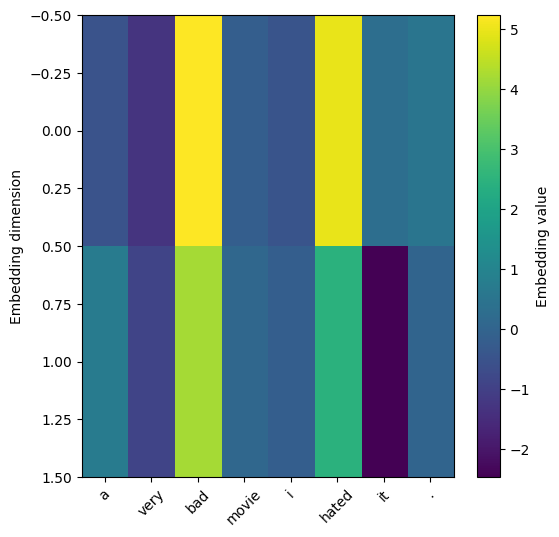

In [ ]:
# Plot the embedding matrix of a review

text = "a very bad movie i hated it."
tokens = tokenizer.encode(text)
tokens = torch.tensor([t for t in tokens if t != -1])  # Ignore invalid tokens

with torch.no_grad():
    embedded = classifier.embedding(tokens)  # Shape: (seq_len, d_embed)

plt.figure(figsize=(6, 6))
plt.imshow(embedded.T, cmap="viridis", aspect="auto")
plt.xticks(
    range(len(tokens)), [tokenizer.id_to_token[t.item()] for t in tokens], rotation=45
)
plt.ylabel("Embedding dimension")

plt.colorbar(label="Embedding value")

## Word embeddings in practice

- Word embeddings can be very powerful but costly to learn.
- An innovative idea was to pre-train word embeddings on a large corpus.
- This is the idea from the paper "Distributed Representations of Words and Phrases and their Compositionality" by Mikolov et al. (2013), which introduced the Word2Vec model.
-
### Word2Vec
- Word2Vec is a contrastive learning model.
- Key Idea: Words with similar contexts (neighboring words) have similar vector representations.


## Word2Vec

1. **Select a Word and Context**  
   - Randomly sample a word $w$ from a document.  
   - Define its **positive context** as the words within a window of size $R$ around $w$, excluding $w$ itself:  
     $$
     \mathcal{C}_{\text{pos}} = [w_{i-R}, \dots, w_{i-1}, w_{i+1}, \dots, w_{i+R}].
     $$

2. **Negative Examples**  
   - To balance the training, introduce **negative examples** by sampling $2KR$ random words from the vocabulary $\mathcal{V}$:  
     $$
     \mathcal{C}_{\text{neg}} = \{c_1, \dots, c_{2KR}\}, \quad c_j \in \mathcal{V}.
     $$

3. **Embedding Words**  
   - Represent the target word $w$ as a vector $\mathbf{v}_w \in \mathbb{R}^d$ using an embeddings table $\mathcal{E}_w$.  
   - Similarly, map each word in $\mathcal{C}_{\text{pos}}$ and $\mathcal{C}_{\text{neg}}$ to vectors:  
     $$
     \mathbf{v}_{\mathcal{C}_{\text{pos}}} \in \mathbb{R}^{2R \times d}, \quad \mathbf{v}_{\mathcal{C}_{\text{neg}}} \in \mathbb{R}^{2KR \times d}.
     $$

4. **Compute Similarity**  
   - For each context word $c$ in $\mathcal{C}_{\text{pos}} \cup \mathcal{C}_{\text{neg}}$, compute the similarity with $w$ using the dot product:  
     $$
     s = \mathbf{v}_c \cdot \mathbf{v}_w.
     $$  
   - Train the model to maximize the similarity between $w$ and the positive context words, and minimize the similarity with the negative context words.
